In [124]:
import pandas as pd
from torch.utils.data import Dataset,DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
device = torch.device('cuda')

In [125]:
torch.manual_seed(42)

In [126]:
df = pd.read_csv('https://raw.githubusercontent.com/mostafizcse007/Deep-Learning/refs/heads/main/Week%202/fmnist_small.csv')

In [127]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


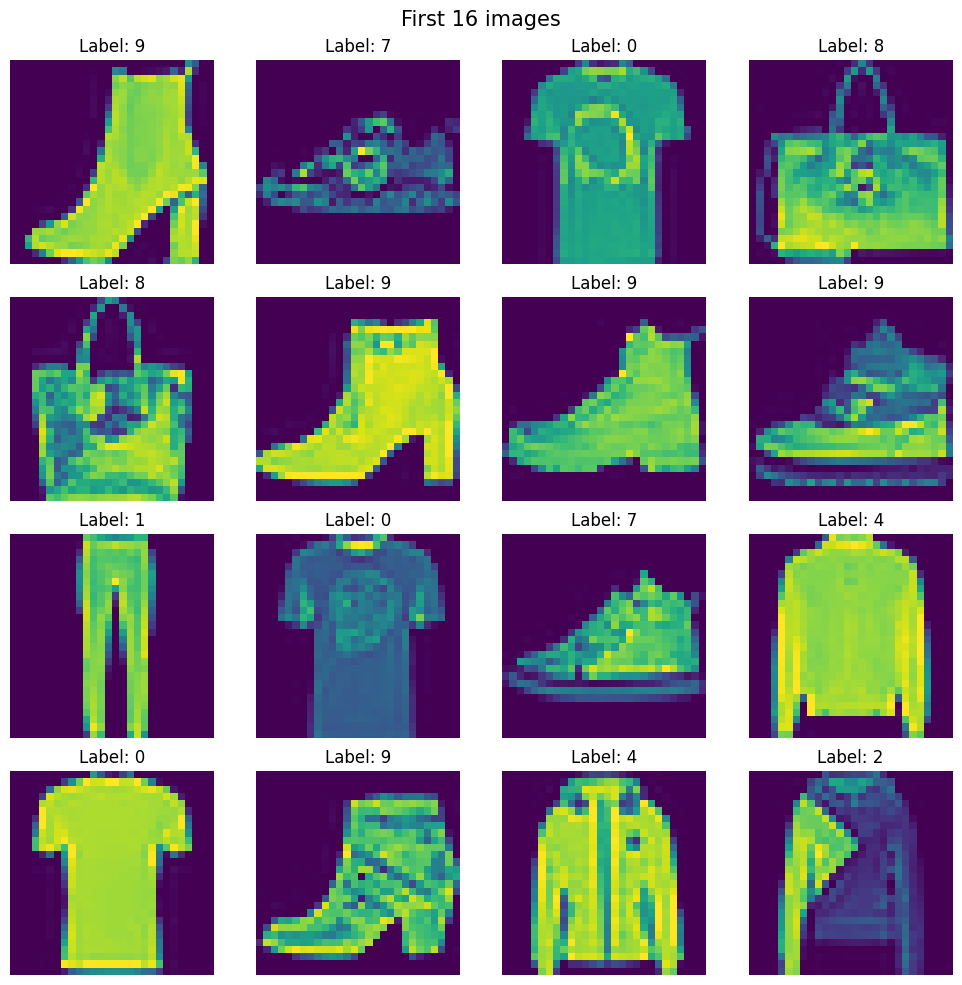

In [128]:
fig,axes = plt.subplots(4,4,figsize=(10,10))
plt.suptitle("First 16 images",fontsize=15)

for i,ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i,0]}")
    plt.tight_layout()
plt.show()

In [129]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [130]:
X = X/255.0

In [131]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

In [132]:
X_train.shape

(4800, 784)

In [133]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        self.features = torch.tensor(features.values,dtype = torch.float32)
        self.labels = torch.tensor(labels.values,dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self,index):
        return self.features[index],self.labels[index]


In [142]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

In [143]:
train_loader = DataLoader(train_dataset,shuffle=True,batch_size=32,pin_memory=True)
test_loader = DataLoader(test_dataset,shuffle=False,batch_size=32,pin_memory=True)

In [156]:
class MyNN(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=.3),    # adding dropout in hidden layers
            nn.Linear(256,128),
            nn.BatchNorm1d(128),    # adding batch normalization
            nn.ReLU(),
            nn.Dropout(p=.3), 
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=.3), 
            nn.Linear(64,10)
        )

    def forward(self,x):
        return self.model(x)

In [157]:
epochs = 300
learning_rate = .01

In [158]:
model = MyNN(X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=learning_rate, weight_decay=1e-4)

In [159]:
for epoch in range(epochs):
    epoch_loss = 0
    for batch_feature,batch_label in train_loader:

        batch_feature = batch_feature.to(device)
        batch_label = batch_label.to(device)

        outputs = model(batch_feature)
        loss = criterion(outputs,batch_label)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}: {epoch_loss/len(train_loader)}")

Epoch 50: 0.5300315883755684
Epoch 100: 0.5195754199226698
Epoch 150: 0.5150734034180641
Epoch 200: 0.488505758245786
Epoch 250: 0.48806111931800844
Epoch 300: 0.49613540291786196


##### Accuracy on train data

In [160]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for batch_feature, batch_label in train_loader:

        batch_feature = batch_feature.to(device)
        batch_label = batch_label.to(device)

        outputs = model(batch_feature)

        _, predicted = torch.max(outputs, 1)

        total += batch_feature.shape[0]
        correct += (predicted == batch_label).sum().item()

print(correct / total)

0.87125


##### Accuracy on test data

In [161]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for batch_feature, batch_label in test_loader:

        batch_feature = batch_feature.to(device)
        batch_label = batch_label.to(device)

        outputs = model(batch_feature)

        _, predicted = torch.max(outputs, 1)

        total += batch_feature.shape[0]
        correct += (predicted == batch_label).sum().item()

print(correct / total)

0.7875
